## Spring Pendulum

Let's solve it using Lagrangian framework

<div align="center">
    <img src="https://ths.rwth-aachen.de/wp-content/uploads/sites/4/research/HyPro/pics/spring_pendulum.png"
         alt="Spring pendulum"
         width="350">
</div>

In [1]:
# basic package
import sympy as smp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

plt.style.use('classic')

In [2]:
# ordinary quantities
m, k, g, l0 = smp.symbols('m k g l0', real = True, positive = True, constant = True) # mass, elastic constant, gravity acceleration and natural length of the spring
t = smp.symbols('t', real = True, nonnegative = True) # time
rho = smp.Function('rho', real = True, positive = True)(t) # distance from origin of the orb
theta = smp.Function('theta', real = True)(t) # angle of the orb with respect to normal axis

# dimensionless quantities
tau = smp.symbols('tau', real = True, nonnegative = True) # dimensionless time
rho_tilde = smp.Function('rho', real = True, positive = True)(tau) # dimensionless distance
theta_tilde = smp.Function('theta', real = True)(tau) # dimensionless angle (for derivatives)
eps = smp.symbols('varepsilon', real = True, positive = True, constant = True) # dimensionless parameter

In [3]:
# compute the kinetic energy
x = rho * smp.cos(theta) # polar coordinates
y = rho * smp.sin(theta)

v_x = smp.diff(x, t, 1)
v_y = smp.diff(y, t, 1)

T = smp.Rational(1, 2) * m * (v_x ** 2 + v_y ** 2)
T.simplify()

m*(rho(t)**2*Derivative(theta(t), t)**2 + Derivative(rho(t), t)**2)/2

In [4]:
# compute the total potential energy
U_k = smp.Rational(1, 2) * k * (rho - l0) ** 2 # potential energy of the spring
U_g = - m * g * rho * smp.cos(theta) # potential energy for gravity
U = U_k + U_g
U.simplify()

-g*m*rho(t)*cos(theta(t)) + k*(l0 - rho(t))**2/2

In [5]:
# compute Lagrangian
L = T - U
L.simplify()

g*m*rho(t)*cos(theta(t)) - k*(l0 - rho(t))**2/2 + m*(rho(t)**2*Derivative(theta(t), t)**2 + Derivative(rho(t), t)**2)/2

In [6]:
# apply Euler-Lagrange equations
eqs = smp.euler_equations(L, (rho, theta), t)
eqs = [smp.Eq(smp.simplify(eq.lhs), 0) for eq in eqs] # simplification
eqs

[Eq(g*m*cos(theta(t)) + k*l0 - k*rho(t) + m*rho(t)*Derivative(theta(t), t)**2 - m*Derivative(rho(t), (t, 2)), 0),
 Eq(-m*(g*sin(theta(t)) + rho(t)*Derivative(theta(t), (t, 2)) + 2*Derivative(rho(t), t)*Derivative(theta(t), t))*rho(t), 0)]

In [7]:
eqs[0] # for rho

Eq(g*m*cos(theta(t)) + k*l0 - k*rho(t) + m*rho(t)*Derivative(theta(t), t)**2 - m*Derivative(rho(t), (t, 2)), 0)

In [8]:
eqs[1] # for theta

Eq(-m*(g*sin(theta(t)) + rho(t)*Derivative(theta(t), (t, 2)) + 2*Derivative(rho(t), t)*Derivative(theta(t), t))*rho(t), 0)

In [9]:
# extract accelerations
a_theta = smp.Derivative(theta, t, 2)
a_rho = smp.Derivative(rho, t, 2)

eqs = smp.solve(eqs, (a_theta, a_rho))
eqs

{Derivative(rho(t), (t, 2)): g*cos(theta(t)) + k*l0/m - k*rho(t)/m + rho(t)*Derivative(theta(t), t)**2,
 Derivative(theta(t), (t, 2)): -g*sin(theta(t))/rho(t) - 2*Derivative(rho(t), t)*Derivative(theta(t), t)/rho(t)}

In [10]:
a_rho = eqs[a_rho]
a_theta = eqs[a_theta]

In [11]:
a_rho # differential equation for rho

g*cos(theta(t)) + k*l0/m - k*rho(t)/m + rho(t)*Derivative(theta(t), t)**2

In [12]:
a_theta # differential equation for theta

-g*sin(theta(t))/rho(t) - 2*Derivative(rho(t), t)*Derivative(theta(t), t)/rho(t)

Before to solve it numerically, we should make it dimensionless. Define:

$$
    \tau = \omega_0 \, t \qquad \omega_0 = \sqrt{\frac{k}{m}}
$$

$$
    \tilde{\rho}(\tau) = \frac{1}{l_0} \, \rho \left( t = \tau / \omega_0 \right)
$$

$$
    \tilde{\theta}(\tau) = \theta \left( t = \tau / \omega_0 \right)
$$

$$
    \varepsilon = \frac{m \, g}{k \, l_0} \qquad \text{Dimensionless positive parameter}
$$

In [13]:
omega0 = smp.sqrt(k / m) # natural angular velocity

dimensionless = { # relations
    rho: rho_tilde * l0,
    theta: theta_tilde,
    smp.Derivative(rho, t, 1): omega0 * l0 * smp.Derivative(rho_tilde, tau, 1),
    smp.Derivative(rho, t, 2): omega0 ** 2 * l0 * smp.Derivative(rho_tilde, tau, 2),
    smp.Derivative(theta, t, 1): omega0 * smp.Derivative(theta_tilde, tau, 1),
    smp.Derivative(theta, t, 2): omega0 ** 2 * smp.Derivative(theta_tilde, tau, 2)
}

In [14]:
# differential equation for rho in dimensionless form
a_rho = (smp.expand(a_rho.subs(dimensionless) / (omega0 ** 2 * l0))).subs(m * g / (k * l0), eps)
a_rho

varepsilon*cos(theta(tau)) + rho(tau)*Derivative(theta(tau), tau)**2 - rho(tau) + 1

In [15]:
# differential equation for rho in dimensionless form
a_theta = (smp.expand(a_theta.subs(dimensionless) / (omega0 ** 2))).subs(m * g / (k * l0), eps)
a_theta

-varepsilon*sin(theta(tau))/rho(tau) - 2*Derivative(rho(tau), tau)*Derivative(theta(tau), tau)/rho(tau)

Now, we move on SciPy

In [16]:
def system(tau, y, epsilon): # system of odes for scipy.integrate.solve_ivp() function

    rho_num, v_rhonum, theta_num, v_thetanum = y # order: rho, v_rho, theta, v_theta
    rho_num = 1e-09 if rho_num < 1e-09 else rho_num

    a_rhonum = epsilon * np.cos(theta_num) + rho_num * v_thetanum ** 2 - rho_num + 1.0
    a_thetanum = - (epsilon * np.sin(theta_num) + 2.0 * v_rhonum * v_thetanum) / rho_num

    return [v_rhonum, a_rhonum, v_thetanum, a_thetanum] # order: v_rho, a_rho, v_theta, a_theta

In [17]:
# computing epsilon and omega0
m, g, k, l0 = (1.5, 9.81, 12.0, 1.0) # a choice of constants
omega0 = np.sqrt(k / m)
eps = m * g / (k * l0)
round(eps, 3), round(omega0, 3)

(1.226, np.float64(2.828))

In [18]:
# initial conditions
initial_distance = 1.1 * l0
initial_radial_vel = 0.0
initial_angle = np.pi / 3.0
initial_angle_vel = 0.0

y0 = [initial_distance, initial_radial_vel, initial_angle, initial_angle_vel] # initial state vector
t = np.linspace(0.0, 30.0, 750) # times at which to store the solution
tau = omega0 * t

In [19]:
sol = solve_ivp( # solve the system with RK-45
    fun = system,
    t_span = (tau[0], tau[-1]),
    y0 = y0,
    args = (eps,),
    t_eval = tau,
    method = 'RK45'
)
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.133e-01 ...  8.474e+01  8.485e+01]
        y: [[ 1.300e+00  1.302e+00 ...  9.611e-01  8.755e-01]
            [ 0.000e+00  3.603e-02 ... -8.348e-01 -6.747e-01]
            [ 1.047e+00  1.042e+00 ...  2.110e-01  1.690e-01]
            [ 0.000e+00 -9.221e-02 ... -3.226e-01 -4.204e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 884
     njev: 0
      nlu: 0

In [20]:
# extract the solution arrays
rho_tilde = sol.y[0]
theta_tilde = sol.y[2]

In [21]:
rho_tilde # rho dimensionless

array([1.3       , 1.30202502, 1.30826336, 1.31919303, 1.33584784,
       1.35933348, 1.39075198, 1.43120175, 1.48177758, 1.54338493,
       1.61630317, 1.70068127, 1.79623589, 1.90223028, 2.01747425,
       2.1403242 , 2.26878968, 2.40123711, 2.53563802, 2.66991293,
       2.8020394 , 2.93005209, 3.05204272, 3.16617931, 3.27089163,
       3.36454981, 3.44567141, 3.51300153, 3.56551283, 3.60240554,
       3.6231074 , 3.6272826 , 3.61473817, 3.58540144, 3.53944196,
       3.4772751 , 3.39956214, 3.30721025, 3.20137244, 3.08342708,
       2.95467821, 2.81661051, 2.67084492, 2.51907228, 2.36305339,
       2.20461892, 2.04566949, 1.88817561, 1.73409084, 1.58509531,
       1.44293114, 1.30930942, 1.18589762, 1.07431957, 0.97618214,
       0.89325355, 0.82728094, 0.77994269, 0.75285684, 0.74758107,
       0.76517826, 0.80546427, 0.86763381, 0.95020938, 1.05117959,
       1.16852096, 1.30011051, 1.44382765, 1.5975562 , 1.75913013,
       1.92634723, 2.09700044, 2.26888537, 2.4398478 , 2.60764

In [22]:
theta_tilde # theta

array([ 1.04719755,  1.04196488,  1.026375  ,  1.0007544 ,  0.96576472,
        0.92232461,  0.87159261,  0.81496713,  0.75408647,  0.69073318,
        0.62647808,  0.56275693,  0.50073189,  0.44128215,  0.38500391,
        0.33221039,  0.2829498 ,  0.23717743,  0.19474561,  0.15545797,
        0.11908474,  0.08536278,  0.05399555,  0.02466052, -0.00285944,
       -0.02874367, -0.05317566, -0.07632741, -0.09835943, -0.11942071,
       -0.13964876, -0.15915737, -0.17802088, -0.19632634, -0.2141541 ,
       -0.23157636, -0.2486572 , -0.26545255, -0.2820102 , -0.298365  ,
       -0.31450195, -0.3304514 , -0.34621505, -0.36174214, -0.37692942,
       -0.3916212 , -0.40560931, -0.4186331 , -0.43036184, -0.4402432 ,
       -0.44745354, -0.4509097 , -0.44926827, -0.44092562, -0.42404247,
       -0.39640355, -0.35621615, -0.30334664, -0.23938604, -0.16765001,
       -0.09340309, -0.02275302,  0.03999363,  0.09256542,  0.13457708,
        0.16694916,  0.19115139,  0.2086428 ,  0.22083427,  0.22

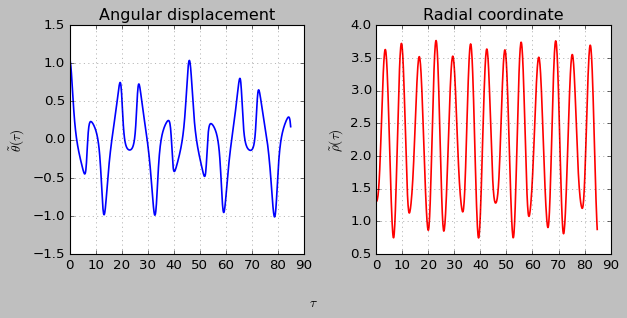

In [23]:
# Fast plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (8, 4), sharex = True)

ax1.plot(tau, theta_tilde, 'b-', linewidth = 1.5)
ax1.set_ylabel(r'$\tilde{\theta}(\tau)$')
ax1.set_title('Angular displacement')
ax1.grid(alpha = 0.5)

ax2.plot(tau, rho_tilde, 'r-', linewidth = 1.5)
ax2.set_ylabel(r'$\tilde{\rho}(\tau)$')
ax2.set_title('Radial coordinate')
ax2.grid(alpha = 0.5)

fig.supxlabel(r'$\tau$')

plt.tight_layout()
plt.show()

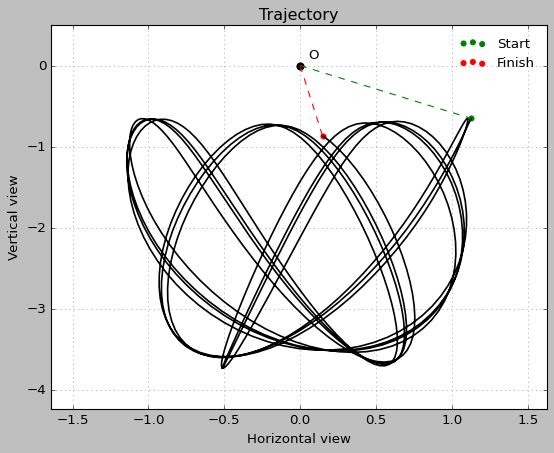

In [24]:
# Trajectory plot
x_tilde = rho_tilde * np.cos(theta_tilde)
y_tilde = rho_tilde * np.sin(theta_tilde)

plt.title('Trajectory')
plt.plot(y_tilde, - x_tilde, linewidth = 1.5, color = 'black')
plt.scatter(y_tilde[0], - x_tilde[0], color = 'green', s = 20, label = 'Start')
plt.scatter(y_tilde[- 1], - x_tilde[- 1], color = 'red', s = 20, label = 'Finish')
plt.scatter(0, 0, color = 'black', s = 40)

plt.plot([0, y_tilde[0]], [0, - x_tilde[0]], color = 'green', linestyle = 'dashed', linewidth = 1)
plt.plot([0, y_tilde[- 1]], [0, - x_tilde[- 1]], color = 'red', linestyle = 'dashed', linewidth = 1)
plt.text(0.05, 0.05, 'O', fontsize = 12, ha = 'left', va = 'bottom')

plt.ylim(min(- x_tilde) - 0.5, 0.5)
plt.xlim(min(y_tilde) - 0.5, max(y_tilde) + 0.5)
plt.xlabel('Horizontal view')
plt.ylabel('Vertical view')
plt.legend(loc = 'best', frameon = False, fontsize = 12)
plt.grid(alpha = 0.5)
plt.show()